# Parte 1 — Análisis Exploratorio
**¿Qué factores históricos predicen al campeón mundial?**

Dataset: 49.000+ partidos internacionales (1872–2026)  
Foco: FIFA World Cup (1.036 partidos)

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
OUTPUTS = Path('../outputs/graficos')
OUTPUTS.mkdir(parents=True, exist_ok=True)

pd.set_option('display.float_format', '{:.2f}'.format)

## 1. Carga y limpieza de datos

In [2]:
df = pd.read_csv('../data/raw/resultados_historicos.csv', parse_dates=['date'])

# Eliminar partidos sin resultado (cancelados / futuros sin score)
df = df.dropna(subset=['home_score', 'away_score']).copy()
df['home_score'] = df['home_score'].astype(int)
df['away_score'] = df['away_score'].astype(int)
df['year'] = df['date'].dt.year
df['total_goles'] = df['home_score'] + df['away_score']

# Resultado desde perspectiva del local
df['resultado'] = np.where(df['home_score'] > df['away_score'], 'Local',
                  np.where(df['home_score'] < df['away_score'], 'Visitante', 'Empate'))

print(f'Partidos con resultado: {len(df):,}')
print(f'Período: {df["year"].min()} – {df["year"].max()}')
print(f'Equipos únicos: {pd.concat([df["home_team"], df["away_team"]]).nunique()}')
df.head(3)

Partidos con resultado: 49,215
Período: 1872 – 2026
Equipos únicos: 333


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year,total_goles,resultado
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False,1872,0,Empate
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False,1873,6,Local
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False,1874,3,Local


In [3]:
# Separar mundiales del resto
wc = df[df['tournament'] == 'FIFA World Cup'].copy()
# Solo mundiales históricos (excluir WC2026 si el dataset los incluye)
wc_hist = wc[wc['year'] <= 2022].copy()

print(f'Partidos de World Cup en el dataset: {len(wc)}')
print(f'Partidos World Cup históricos (≤2022): {len(wc_hist)}')
print(f'Ediciones: {sorted(wc_hist["year"].unique())}')

Partidos de World Cup en el dataset: 964
Partidos World Cup históricos (≤2022): 964
Ediciones: [np.int32(1930), np.int32(1934), np.int32(1938), np.int32(1950), np.int32(1954), np.int32(1958), np.int32(1962), np.int32(1966), np.int32(1970), np.int32(1974), np.int32(1978), np.int32(1982), np.int32(1986), np.int32(1990), np.int32(1994), np.int32(1998), np.int32(2002), np.int32(2006), np.int32(2010), np.int32(2014), np.int32(2018), np.int32(2022)]


## 2. Goles promedio por partido a lo largo del tiempo

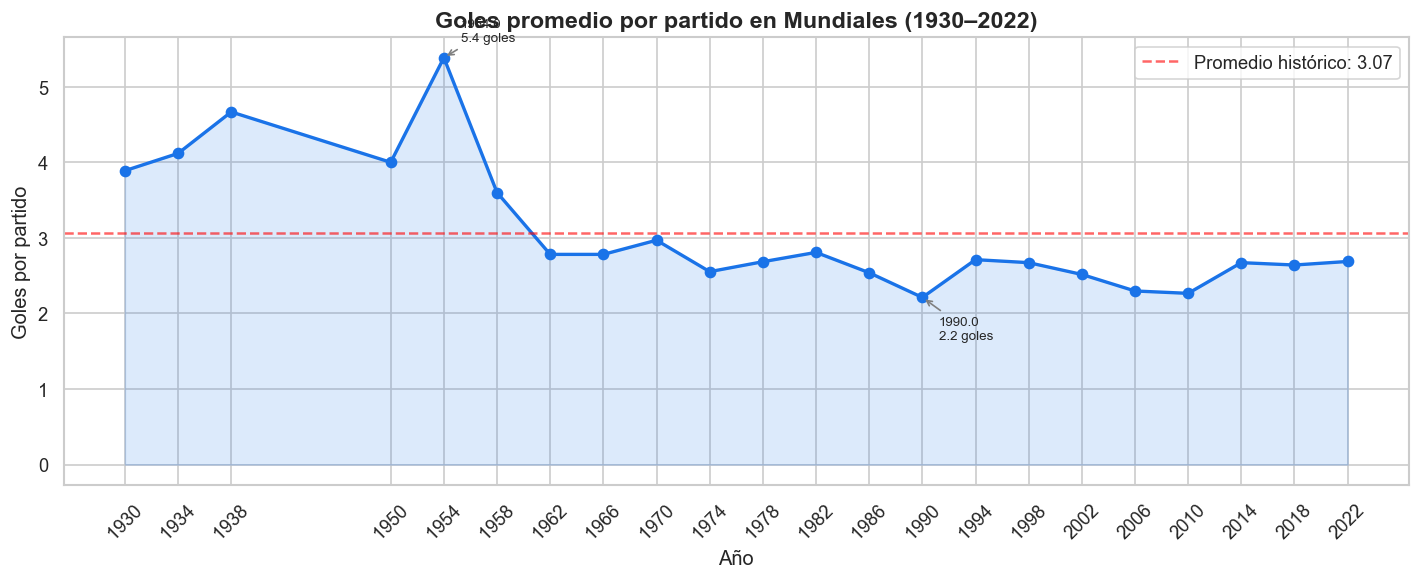

 year  promedio  total  partidos
 1930      3.89     70        18
 1934      4.12     70        17
 1938      4.67     84        18
 1950      4.00     88        22
 1954      5.38    140        26
 1958      3.60    126        35
 1962      2.78     89        32
 1966      2.78     89        32
 1970      2.97     95        32
 1974      2.55     97        38
 1978      2.68    102        38
 1982      2.81    146        52
 1986      2.54    132        52
 1990      2.21    115        52
 1994      2.71    141        52
 1998      2.67    171        64
 2002      2.52    161        64
 2006      2.30    147        64
 2010      2.27    145        64
 2014      2.67    171        64
 2018      2.64    169        64
 2022      2.69    172        64


In [4]:
goles_anio = wc_hist.groupby('year')['total_goles'].agg(['mean', 'sum', 'count']).reset_index()
goles_anio.columns = ['year', 'promedio', 'total', 'partidos']

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(goles_anio['year'], goles_anio['promedio'], marker='o', linewidth=2,
        color='#1a73e8', markersize=6)
ax.fill_between(goles_anio['year'], goles_anio['promedio'], alpha=0.15, color='#1a73e8')

# Anotar valores extremos
idx_max = goles_anio['promedio'].idxmax()
idx_min = goles_anio['promedio'].idxmin()
for idx, label in [(idx_max, 'Máximo'), (idx_min, 'Mínimo')]:
    row = goles_anio.loc[idx]
    ax.annotate(f"{row['year']}\n{row['promedio']:.1f} goles",
                xy=(row['year'], row['promedio']),
                xytext=(10, 10 if idx == idx_max else -25),
                textcoords='offset points', fontsize=8,
                arrowprops=dict(arrowstyle='->', color='gray'))

ax.axhline(goles_anio['promedio'].mean(), color='red', linestyle='--',
           alpha=0.6, label=f'Promedio histórico: {goles_anio["promedio"].mean():.2f}')
ax.set_title('Goles promedio por partido en Mundiales (1930–2022)', fontsize=14, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Goles por partido')
ax.legend()
ax.set_xticks(goles_anio['year'])
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(OUTPUTS / 'goles_por_anio.png', dpi=150, bbox_inches='tight')
plt.show()
print(goles_anio.to_string(index=False))

## 3. Victoria local vs visitante vs empate

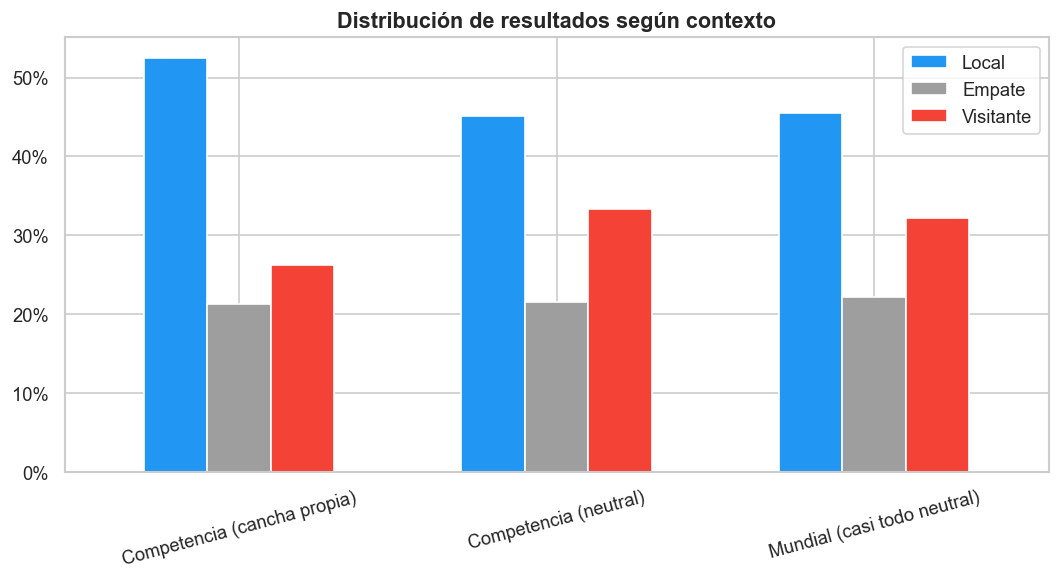

          Competencia (cancha propia) Competencia (neutral)  \
resultado                                                     
Local                           52.5%                 45.1%   
Visitante                       26.3%                 33.4%   
Empate                          21.3%                 21.5%   

          Mundial (casi todo neutral)  
resultado                              
Local                           45.5%  
Visitante                       32.3%  
Empate                          22.2%  


C:\Users\bruno\AppData\Local\Temp\ipykernel_16080\535617966.py:26: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(comparacion.applymap(lambda x: f'{x:.1%}'))


In [5]:
# Comparación: Mundiales vs todos los partidos (con y sin neutral)
def tasas_resultado(data, label):
    t = data['resultado'].value_counts(normalize=True).rename(label)
    return t

df_nofriendly = df[df['tournament'] != 'Friendly']
comparacion = pd.DataFrame([
    tasas_resultado(df_nofriendly[~df_nofriendly['neutral']], 'Competencia (cancha propia)'),
    tasas_resultado(df_nofriendly[df_nofriendly['neutral']], 'Competencia (neutral)'),
    tasas_resultado(wc_hist, 'Mundial (casi todo neutral)'),
]).T

fig, ax = plt.subplots(figsize=(9, 5))
comparacion.loc[['Local', 'Empate', 'Visitante']].T.plot(
    kind='bar', ax=ax, color=['#2196F3', '#9E9E9E', '#F44336'],
    width=0.6, edgecolor='white'
)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Distribución de resultados según contexto', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=15)
ax.legend(title='')
plt.tight_layout()
plt.savefig(OUTPUTS / 'resultados_por_contexto.png', dpi=150, bbox_inches='tight')
plt.show()
print(comparacion.applymap(lambda x: f'{x:.1%}'))

## 4. Campeones históricos — ¿quién gana más?

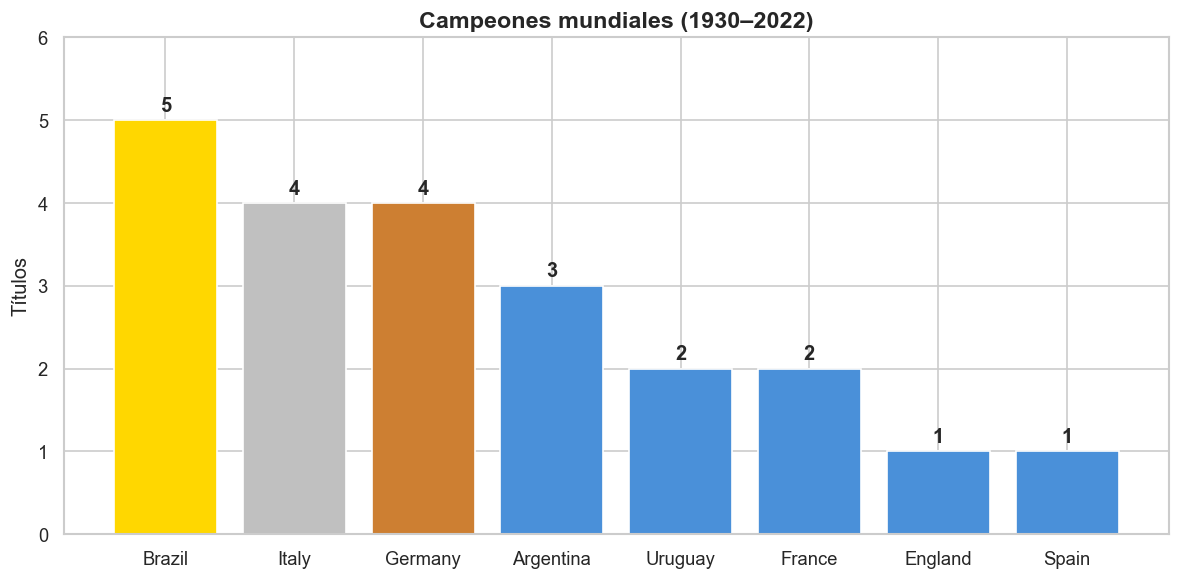

In [6]:
# Campeones por Mundial (1930–2022)
campeones = {
    1930: 'Uruguay', 1934: 'Italy', 1938: 'Italy', 1950: 'Uruguay',
    1954: 'Germany', 1958: 'Brazil', 1962: 'Brazil', 1966: 'England',
    1970: 'Brazil', 1974: 'Germany', 1978: 'Argentina', 1982: 'Italy',
    1986: 'Argentina', 1990: 'Germany', 1994: 'Brazil', 1998: 'France',
    2002: 'Brazil', 2006: 'Italy', 2010: 'Spain', 2014: 'Germany',
    2018: 'France', 2022: 'Argentina'
}
s_camp = pd.Series(campeones, name='campeon').rename_axis('year').reset_index()
conteo = s_camp['campeon'].value_counts().reset_index()
conteo.columns = ['pais', 'titulos']

colores = ['#FFD700' if i == 0 else '#C0C0C0' if i == 1 else '#CD7F32' if i == 2
           else '#4a90d9' for i in range(len(conteo))]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(conteo['pais'], conteo['titulos'], color=colores, edgecolor='white')
ax.bar_label(bars, padding=3, fontweight='bold')
ax.set_title('Campeones mundiales (1930–2022)', fontsize=14, fontweight='bold')
ax.set_ylabel('Títulos')
ax.set_yticks(range(0, conteo['titulos'].max() + 2))
plt.tight_layout()
plt.savefig(OUTPUTS / 'campeones_historicos.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Rendimiento por confederación

In [7]:
# Mapa equipo → confederación (basado en equipos del dataset histórico)
equipos_2026 = pd.read_csv('../data/raw/mundial2026_equipos.csv')

# Nombres en inglés para cruzar con el dataset histórico
nombre_map = {
    'Argentina': 'Argentina', 'Brasil': 'Brazil', 'Francia': 'France',
    'España': 'Spain', 'Inglaterra': 'England', 'Portugal': 'Portugal',
    'Países Bajos': 'Netherlands', 'Bélgica': 'Belgium', 'Alemania': 'Germany',
    'Uruguay': 'Uruguay', 'Colombia': 'Colombia', 'Marruecos': 'Morocco',
    'Croacia': 'Croatia', 'Suiza': 'Switzerland', 'Japón': 'Japan',
    'México': 'Mexico', 'Senegal': 'Senegal', 'Ecuador': 'Ecuador',
    'Australia': 'Australia', 'Corea del Sur': 'South Korea',
    'Estados Unidos': 'United States', 'Irán': 'Iran', 'Turquía': 'Turkey',
    'Austria': 'Austria', 'Canadá': 'Canada', 'Noruega': 'Norway',
    'Escocia': 'Scotland', 'Suecia': 'Sweden', 'Túnez': 'Tunisia',
    'Costa de Marfil': 'Ivory Coast', 'Arabia Saudita': 'Saudi Arabia',
    'Ghana': 'Ghana', 'Egipto': 'Egypt', 'Panamá': 'Panama',
    'Paraguay': 'Paraguay', 'Argelia': 'Algeria', 'Irak': 'Iraq',
    'Jordania': 'Jordan', 'Congo DR': 'DR Congo', 'Uzbekistán': 'Uzbekistan',
    'Sudáfrica': 'South Africa', 'Chequia': 'Czech Republic',
    'Catar': 'Qatar', 'Bosnia Herzegovina': 'Bosnia and Herzegovina',
    'Haití': 'Haiti', 'Curazao': 'Curaçao', 'Nueva Zelanda': 'New Zealand',
    'Cabo Verde': 'Cape Verde'
}
equipos_2026['equipo_en'] = equipos_2026['equipo'].map(nombre_map)
conf_map = dict(zip(equipos_2026['equipo_en'], equipos_2026['confederacion']))

# Partidos de mundiales con confederación asignada
wc_hist2 = wc_hist.copy()
wc_hist2['conf_home'] = wc_hist2['home_team'].map(conf_map)
wc_hist2['conf_away'] = wc_hist2['away_team'].map(conf_map)

print('Equipos en mundiales sin confederación asignada:')
sin_conf = set(pd.concat([wc_hist2[wc_hist2['conf_home'].isna()]['home_team'],
                           wc_hist2[wc_hist2['conf_away'].isna()]['away_team']]).unique())
print(sorted(sin_conf)[:20])

Equipos en mundiales sin confederación asignada:
['Angola', 'Bolivia', 'Bulgaria', 'Cameroon', 'Chile', 'China PR', 'Costa Rica', 'Cuba', 'Czechoslovakia', 'Denmark', 'El Salvador', 'German DR', 'Greece', 'Honduras', 'Hungary', 'Iceland', 'Indonesia', 'Israel', 'Italy', 'Jamaica']


In [8]:
# Mapa completo de confederaciones para equipos históricos no en 2026
conf_extra = {
    'Italy': 'UEFA', 'West Germany': 'UEFA', 'Soviet Union': 'UEFA',
    'Yugoslavia': 'UEFA', 'Czechoslovakia': 'UEFA', 'Romania': 'UEFA',
    'Hungary': 'UEFA', 'Poland': 'UEFA', 'Sweden': 'UEFA',
    'Denmark': 'UEFA', 'Bulgaria': 'UEFA', 'Belgium': 'UEFA',
    'Wales': 'UEFA', 'Northern Ireland': 'UEFA', 'Serbia': 'UEFA',
    'Ukraine': 'UEFA', 'Russia': 'UEFA', 'Turkey': 'UEFA',
    'Slovenia': 'UEFA', 'Slovakia': 'UEFA', 'Greece': 'UEFA',
    'Republic of Ireland': 'UEFA', 'Switzerland': 'UEFA',
    'Chile': 'CONMEBOL', 'Peru': 'CONMEBOL', 'Bolivia': 'CONMEBOL',
    'Venezuela': 'CONMEBOL', 'Cuba': 'CONCACAF', 'Honduras': 'CONCACAF',
    'El Salvador': 'CONCACAF', 'Costa Rica': 'CONCACAF', 'Trinidad and Tobago': 'CONCACAF',
    'Jamaica': 'CONCACAF', 'Netherlands Antilles': 'CONCACAF',
    'Cameroon': 'CAF', 'Nigeria': 'CAF', 'Zaire': 'CAF', 'Angola': 'CAF',
    'Togo': 'CAF', 'Zambia': 'CAF', 'Mozambique': 'CAF', 'Kenya': 'CAF',
    'Gabon': 'CAF', 'Benin': 'CAF', 'Mali': 'CAF', 'Uganda': 'CAF',
    'North Korea': 'AFC', 'Kuwait': 'AFC', 'UAE': 'AFC',
    'Indonesia': 'AFC', 'China': 'AFC', 'Bahrain': 'AFC',
    'New Zealand': 'OFC', 'Australia': 'AFC',
    'United States': 'CONCACAF', 'Czech Republic': 'UEFA',
    'Ivory Coast': 'CAF', 'DR Congo': 'CAF', 'Cape Verde': 'CAF'
}
full_conf_map = {**conf_map, **conf_extra}

wc_hist2['conf_home'] = wc_hist2['home_team'].map(full_conf_map)
wc_hist2['conf_away'] = wc_hist2['away_team'].map(full_conf_map)

# Wins por confederación
conf_wins = []
for _, row in wc_hist2.iterrows():
    if row['resultado'] == 'Local' and pd.notna(row['conf_home']):
        conf_wins.append(row['conf_home'])
    elif row['resultado'] == 'Visitante' and pd.notna(row['conf_away']):
        conf_wins.append(row['conf_away'])

wins_df = pd.Series(conf_wins).value_counts().reset_index()
wins_df.columns = ['confederacion', 'victorias']
print(wins_df)

  confederacion  victorias
0          UEFA        466
1      CONMEBOL        185
2           CAF         37
3      CONCACAF         34
4           AFC         26


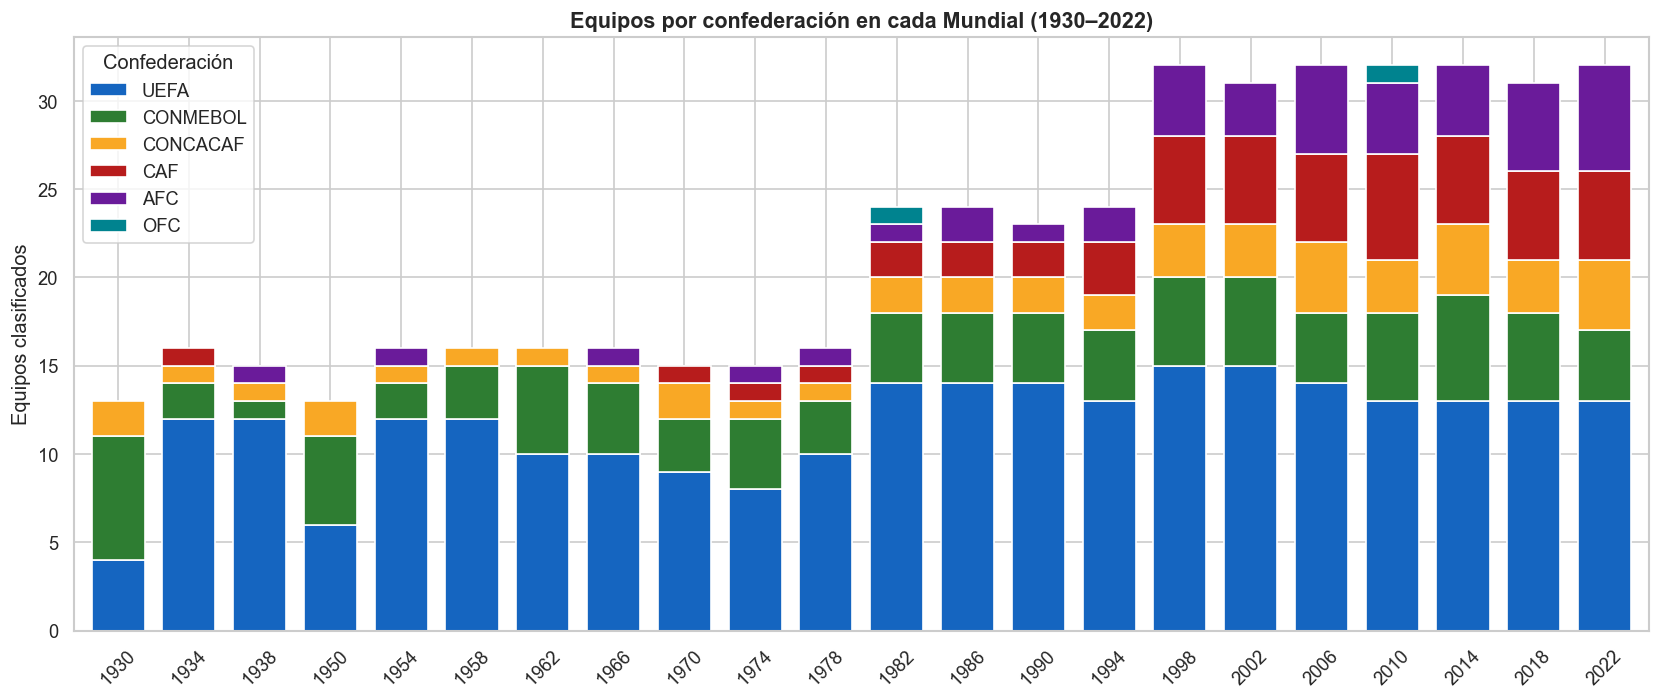

In [9]:
# Presencia por confederación en cada Mundial (cuántos equipos clasificaron)
# Necesitamos saber qué equipos participaron en cada edición
wc_teams_by_year = {}
for year in sorted(wc_hist2['year'].unique()):
    yr = wc_hist2[wc_hist2['year'] == year]
    teams = set(yr['home_team'].tolist() + yr['away_team'].tolist())
    wc_teams_by_year[year] = teams

rows = []
for year, teams in wc_teams_by_year.items():
    for team in teams:
        conf = full_conf_map.get(team)
        if conf:
            rows.append({'year': year, 'confederacion': conf, 'equipo': team})

presencia_df = pd.DataFrame(rows)
pivot = presencia_df.groupby(['year', 'confederacion'])['equipo'].count().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))
conf_order = ['UEFA', 'CONMEBOL', 'CONCACAF', 'CAF', 'AFC', 'OFC']
conf_colors = {'UEFA': '#1565C0', 'CONMEBOL': '#2E7D32', 'CONCACAF': '#F9A825',
               'CAF': '#B71C1C', 'AFC': '#6A1B9A', 'OFC': '#00838F'}
pivot[[c for c in conf_order if c in pivot.columns]].plot(
    kind='bar', ax=ax, stacked=True,
    color=[conf_colors[c] for c in conf_order if c in pivot.columns],
    width=0.75, edgecolor='white'
)
ax.set_title('Equipos por confederación en cada Mundial (1930–2022)', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Equipos clasificados')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Confederación', loc='upper left')
plt.tight_layout()
plt.savefig(OUTPUTS / 'confederaciones_por_anio.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. ¿Cuántas sorpresas hay en mundiales?

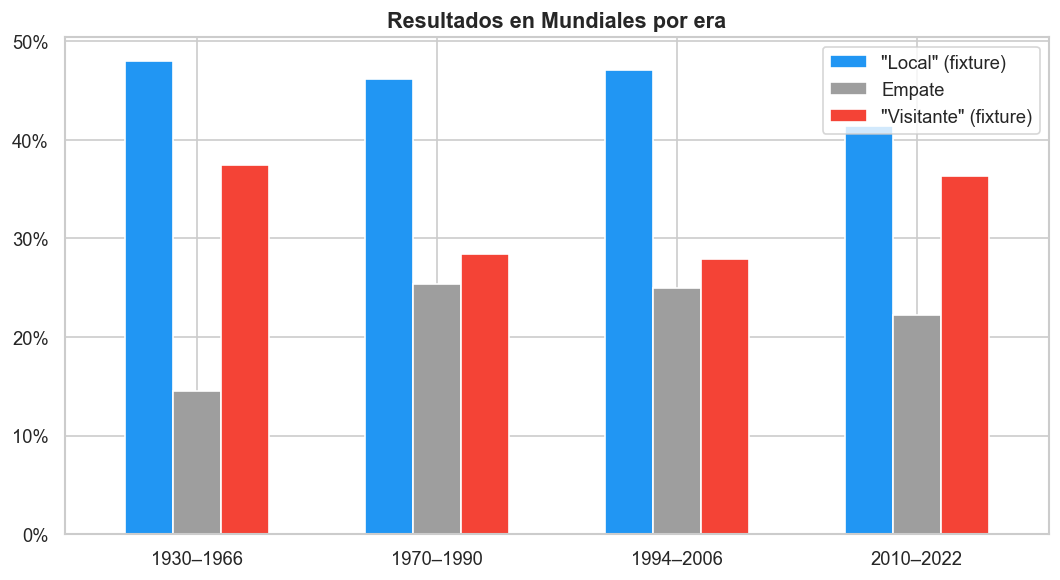

resultado Empate  Local Visitante
era                              
1930–1966  14.5%  48.0%     37.5%
1970–1990  25.4%  46.2%     28.4%
1994–2006  25.0%  47.1%     27.9%
2010–2022  22.3%  41.4%     36.3%


C:\Users\bruno\AppData\Local\Temp\ipykernel_16080\3884184055.py:31: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(era_stats.applymap(lambda x: f'{x:.1%}'))


In [10]:
# "Sorpresa" = gana el equipo con MÁS goles recibidos en el torneo (proxy simple)
# Mejor proxy: el equipo visitante gana (en mundiales casi todo es neutral,
# pero el "visitante" en fixture suele ser el peor rankeado)

# Análisis por era
def era(year):
    if year <= 1966: return '1930–1966'
    elif year <= 1990: return '1970–1990'
    elif year <= 2006: return '1994–2006'
    else: return '2010–2022'

wc_hist2['era'] = wc_hist2['year'].map(era)

# Tasas de resultado por era en mundiales
era_stats = wc_hist2.groupby(['era', 'resultado']).size().unstack(fill_value=0)
era_stats = era_stats.div(era_stats.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(9, 5))
era_stats[['Local', 'Empate', 'Visitante']].plot(
    kind='bar', ax=ax, color=['#2196F3', '#9E9E9E', '#F44336'],
    width=0.6, edgecolor='white'
)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Resultados en Mundiales por era', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
ax.legend(['"Local" (fixture)', 'Empate', '"Visitante" (fixture)'])
plt.tight_layout()
plt.savefig(OUTPUTS / 'resultados_por_era.png', dpi=150, bbox_inches='tight')
plt.show()
print(era_stats.applymap(lambda x: f'{x:.1%}'))

## 7. Goles en fases del torneo

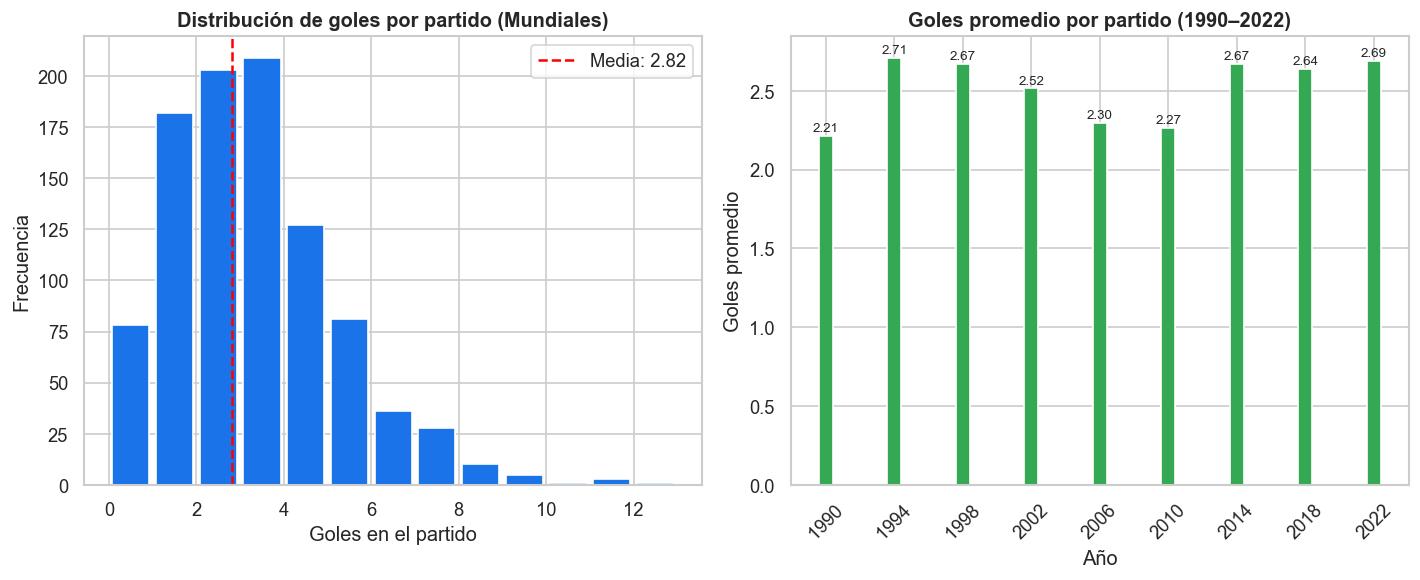

In [11]:
# Distribución de goles por partido
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histograma goles totales
axes[0].hist(wc_hist2['total_goles'], bins=range(0, 14), color='#1a73e8',
             edgecolor='white', rwidth=0.85)
axes[0].set_title('Distribución de goles por partido (Mundiales)', fontweight='bold')
axes[0].set_xlabel('Goles en el partido')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(wc_hist2['total_goles'].mean(), color='red', linestyle='--',
                label=f'Media: {wc_hist2["total_goles"].mean():.2f}')
axes[0].legend()

# Goles por edición del mundial reciente
goles_reciente = wc_hist2[wc_hist2['year'] >= 1990].groupby('year')['total_goles'].mean()
axes[1].bar(goles_reciente.index, goles_reciente.values, color='#34A853', edgecolor='white')
axes[1].set_title('Goles promedio por partido (1990–2022)', fontweight='bold')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Goles promedio')
axes[1].set_xticks(goles_reciente.index)
axes[1].tick_params(axis='x', rotation=45)
for i, (year, val) in enumerate(goles_reciente.items()):
    axes[1].text(year, val + 0.03, f'{val:.2f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUTS / 'distribucion_goles.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Top selecciones: partidos ganados en mundiales

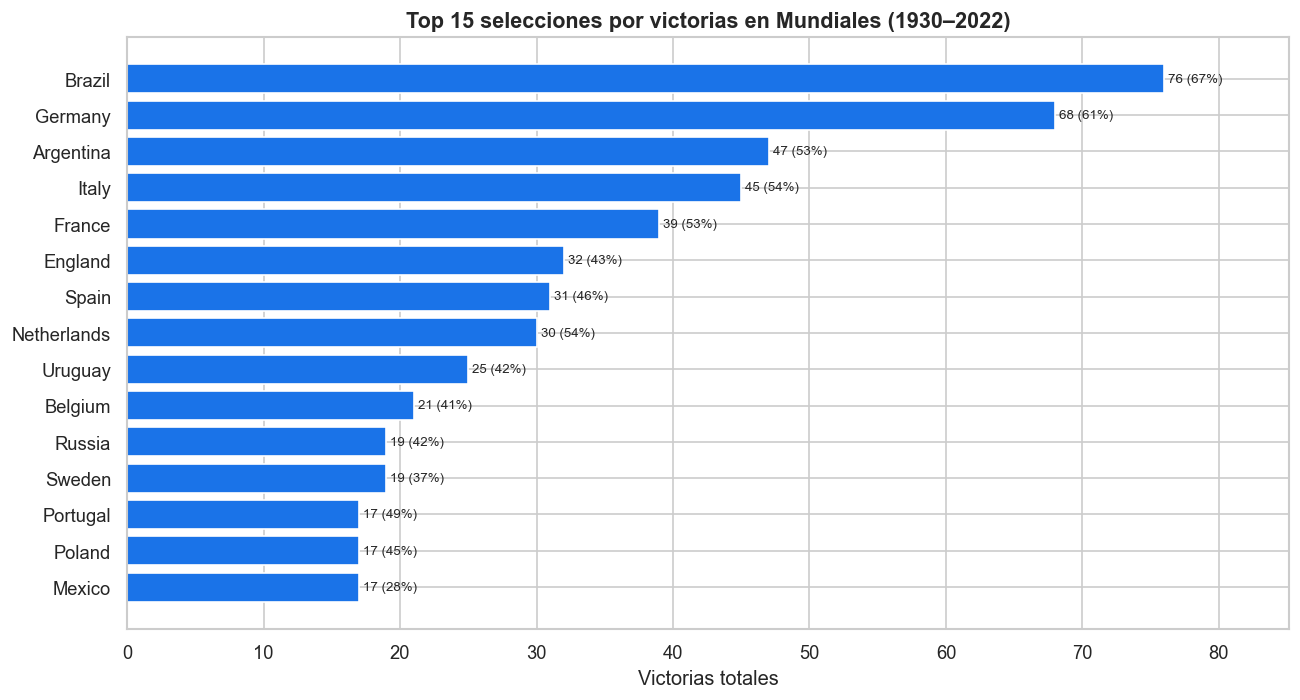

In [12]:
# Victorias totales en mundiales por selección
wins_home = wc_hist2[wc_hist2['resultado'] == 'Local']['home_team'].value_counts()
wins_away = wc_hist2[wc_hist2['resultado'] == 'Visitante']['away_team'].value_counts()
draws_home = wc_hist2[wc_hist2['resultado'] == 'Empate']['home_team'].value_counts()
draws_away = wc_hist2[wc_hist2['resultado'] == 'Empate']['away_team'].value_counts()

total_wins = (wins_home.add(wins_away, fill_value=0)).sort_values(ascending=False)
total_draws = (draws_home.add(draws_away, fill_value=0))

top_n = 15
top_teams = total_wins.head(top_n).index

# Partidos jugados
played_home = wc_hist2.groupby('home_team').size()
played_away = wc_hist2.groupby('away_team').size()
total_played = played_home.add(played_away, fill_value=0)

wins_pct = (total_wins / total_played * 100).round(1)

top_df = pd.DataFrame({
    'victorias': total_wins[top_teams],
    'empates': total_draws.reindex(top_teams, fill_value=0),
    'pct_victorias': wins_pct.reindex(top_teams)
}).fillna(0)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(top_df.index[::-1], top_df['victorias'][::-1],
               color='#1a73e8', edgecolor='white')
for i, (team, row) in enumerate(top_df[::-1].iterrows()):
    ax.text(row['victorias'] + 0.3, i,
            f"{int(row['victorias'])} ({row['pct_victorias']:.0f}%)",
            va='center', fontsize=8)
ax.set_title(f'Top {top_n} selecciones por victorias en Mundiales (1930–2022)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Victorias totales')
ax.margins(x=0.12)
plt.tight_layout()
plt.savefig(OUTPUTS / 'top_victorias_mundiales.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Experiencia mundialista de los equipos 2026

In [13]:
# Win rate histórico en mundiales para los 48 equipos clasificados a 2026
equipos_2026['equipo_en'] = equipos_2026['equipo'].map(nombre_map)

stats_2026 = []
for _, row in equipos_2026.iterrows():
    team_en = row['equipo_en']
    if pd.isna(team_en):
        continue
    partidos = wc_hist2[(wc_hist2['home_team'] == team_en) |
                         (wc_hist2['away_team'] == team_en)]
    if len(partidos) == 0:
        stats_2026.append({'equipo': row['equipo'], 'grupo': row['grupo'],
                           'partidos_wc': 0, 'victorias_wc': 0, 'win_rate_wc': 0,
                           'ranking_fifa': row['ranking_fifa']})
        continue
    wins = ((partidos['home_team'] == team_en) & (partidos['resultado'] == 'Local')).sum() + \
           ((partidos['away_team'] == team_en) & (partidos['resultado'] == 'Visitante')).sum()
    stats_2026.append({
        'equipo': row['equipo'], 'grupo': row['grupo'],
        'partidos_wc': len(partidos), 'victorias_wc': wins,
        'win_rate_wc': wins / len(partidos) * 100,
        'ranking_fifa': row['ranking_fifa']
    })

stats_df = pd.DataFrame(stats_2026).sort_values('win_rate_wc', ascending=False)
print('Win rate en Mundiales — Top 15:')
print(stats_df.head(15)[['equipo', 'partidos_wc', 'victorias_wc', 'win_rate_wc']]
      .to_string(index=False))

Win rate en Mundiales — Top 15:
      equipo  partidos_wc  victorias_wc  win_rate_wc
      Brasil          114            76        66.67
    Alemania          112            68        60.71
Países Bajos           55            30        54.55
     Francia           73            39        53.42
   Argentina           88            47        53.41
     Turquía           10             5        50.00
    Portugal           35            17        48.57
      España           67            31        46.27
     Croacia           30            13        43.33
  Inglaterra           74            32        43.24
     Uruguay           59            25        42.37
     Senegal           12             5        41.67
     Austria           29            12        41.38
     Bélgica           51            21        41.18
    Colombia           22             9        40.91


In [14]:
# Scatter: Ranking FIFA vs Win rate histórico en mundiales
stats_plot = stats_df[stats_df['partidos_wc'] >= 5].copy()

fig = px.scatter(
    stats_plot, x='ranking_fifa', y='win_rate_wc',
    text='equipo', size='partidos_wc', color='win_rate_wc',
    color_continuous_scale='RdYlGn',
    title='Ranking FIFA vs Win Rate histórico en Mundiales (equipos 2026)',
    labels={'ranking_fifa': 'Ranking FIFA (menor = mejor)',
            'win_rate_wc': 'Win rate en mundiales (%)',
            'partidos_wc': 'Partidos jugados'}
)
fig.update_traces(textposition='top center', textfont_size=9)
fig.update_layout(showlegend=False, height=550)
fig.write_html(str(OUTPUTS / 'ranking_vs_winrate.html'))
fig.show()

## 10. Resumen de hallazgos para el modelo

In [15]:
print('=== HALLAZGOS CLAVE ===')
print(f'\n1. Goles promedio: {wc_hist2["total_goles"].mean():.2f} por partido en mundiales')

tasas = wc_hist2['resultado'].value_counts(normalize=True)
print(f'\n2. Resultados en mundiales:')
for res, pct in tasas.items():
    print(f'   {res}: {pct:.1%}')

print(f'\n3. Campeones únicos: {len(conteo)} países ganaron el Mundial')
print(f'   Sólo UEFA y CONMEBOL han ganado')

print(f'\n4. Top 3 por victorias totales en mundiales:')
for team, wins in total_wins.head(3).items():
    print(f'   {team}: {int(wins)} victorias ({wins_pct[team]:.0f}% win rate)')

print(f'\n5. Equipos debutantes en WC2026: {(stats_df["partidos_wc"] == 0).sum()} selecciones')

=== HALLAZGOS CLAVE ===

1. Goles promedio: 2.82 por partido en mundiales

2. Resultados en mundiales:
   Local: 45.5%
   Visitante: 32.3%
   Empate: 22.2%

3. Campeones únicos: 8 países ganaron el Mundial
   Sólo UEFA y CONMEBOL han ganado

4. Top 3 por victorias totales en mundiales:
   Brazil: 76 victorias (67% win rate)
   Germany: 68 victorias (61% win rate)
   Argentina: 47 victorias (53% win rate)

5. Equipos debutantes en WC2026: 4 selecciones
